In [2]:
import pandas as pd
df = pd.read_csv("ai_impact_jobs_2010_2025_GOLD.csv")
print(df.head())
print(df.columns)

                                 job_id  posting_year    country  \
0  5e739937-d1b0-44d7-935c-7ebb3fc1f6e8          2014     Taiwan   
1  1da6731c-2a17-4fde-b43a-3281912bc31d          2016     Jordan   
2  85cccc9e-f1c0-4b09-80c0-ab91b09d6f6b          2014       Peru   
3  510a083d-c929-452e-bca9-2224547c3f26          2011  Australia   
4  e39cdd94-1247-4380-89db-56c8a4b84f06          2017      China   

          region       city         company_name company_size       industry  \
0      East Asia     Sydney  Future Technologies        Small  Manufacturing   
1    Middle East  Singapore        Prime Systems       Medium     Healthcare   
2  South America      Paris    NextGen Solutions        Large     Healthcare   
3        Oceania      Tokyo        Prime Systems      Startup    Agriculture   
4      East Asia  Singapore       Global Systems   Enterprise           Tech   

            job_title seniority_level  ...  ai_intensity_score  \
0         ML Engineer            Lead  ...  

In [3]:
ai_intensity_by_year = (
    df.groupby("posting_year")["ai_intensity_score"]
    .mean()
    .reset_index()
    .sort_values("posting_year")
)

print(ai_intensity_by_year)

    posting_year  ai_intensity_score
0           2010            0.153696
1           2011            0.155417
2           2012            0.140773
3           2013            0.174034
4           2014            0.192432
5           2015            0.197429
6           2016            0.181941
7           2017            0.181893
8           2018            0.321166
9           2019            0.276842
10          2020            0.314886
11          2021            0.315632
12          2022            0.440374
13          2023            0.452881
14          2024            0.508802
15          2025            0.443901


In [4]:
ai_presence_by_year = (
    df.groupby("posting_year")["ai_mentioned"]
    .mean()
    .reset_index()
    .sort_values("posting_year")
)

# convertir a porcentaje
ai_presence_by_year["ai_mentioned"] = ai_presence_by_year["ai_mentioned"] * 100

print(ai_presence_by_year)

    posting_year  ai_mentioned
0           2010      9.782609
1           2011     10.119048
2           2012      8.287293
3           2013     11.363636
4           2014     16.756757
5           2015     17.714286
6           2016     13.529412
7           2017     13.017751
8           2018     38.036810
9           2019     30.409357
10          2020     36.931818
11          2021     37.356322
12          2022     59.358289
13          2023     58.757062
14          2024     70.312500
15          2025     62.637363


In [5]:
year_stats = (
    df.groupby("posting_year")
    .agg(
        mean_ai_intensity=("ai_intensity_score", "mean"),
        ai_share=("ai_mentioned", "mean"),
        num_jobs=("job_id", "count")
    )
    .reset_index()
    .sort_values("posting_year")
)

# porcentaje
year_stats["ai_share"] = year_stats["ai_share"] * 100

print(year_stats)

    posting_year  mean_ai_intensity   ai_share  num_jobs
0           2010           0.153696   9.782609       184
1           2011           0.155417  10.119048       168
2           2012           0.140773   8.287293       181
3           2013           0.174034  11.363636       176
4           2014           0.192432  16.756757       185
5           2015           0.197429  17.714286       175
6           2016           0.181941  13.529412       170
7           2017           0.181893  13.017751       169
8           2018           0.321166  38.036810       163
9           2019           0.276842  30.409357       171
10          2020           0.314886  36.931818       176
11          2021           0.315632  37.356322       174
12          2022           0.440374  59.358289       187
13          2023           0.452881  58.757062       177
14          2024           0.508802  70.312500       192
15          2025           0.443901  62.637363       182


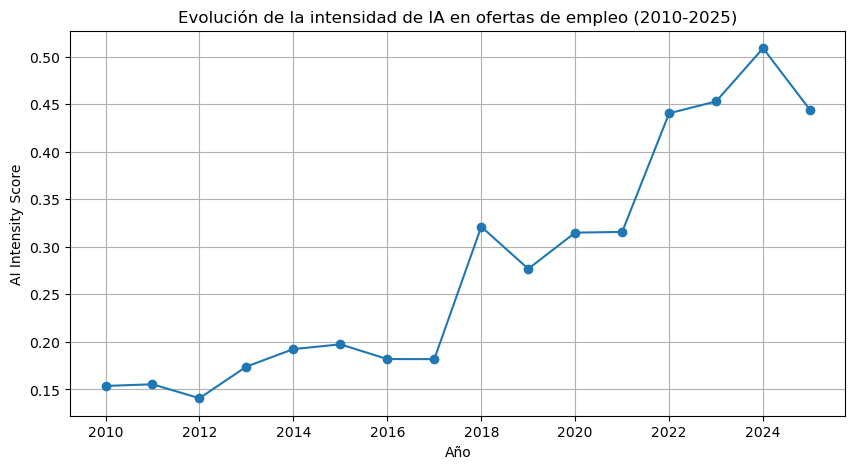

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(year_stats["posting_year"], year_stats["mean_ai_intensity"], marker="o")

plt.title("Evolución de la intensidad de IA en ofertas de empleo (2010-2025)")
plt.xlabel("Año")
plt.ylabel("AI Intensity Score")
plt.grid(True)

plt.show()

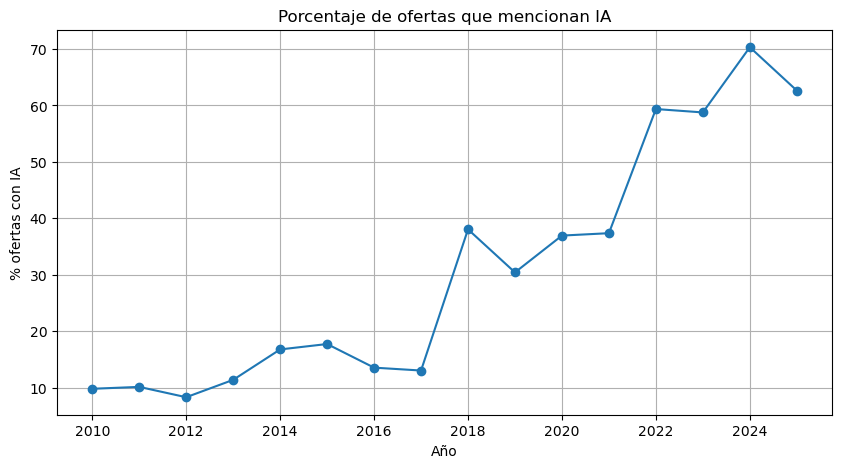

In [7]:
plt.figure(figsize=(10,5))

plt.plot(year_stats["posting_year"], year_stats["ai_share"], marker="o")

plt.title("Porcentaje de ofertas que mencionan IA")
plt.xlabel("Año")
plt.ylabel("% ofertas con IA")

plt.grid(True)
plt.show()